In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [27]:
dataset = "iris.csv"

df = pd.read_csv(dataset, header=None)

species_to_num = {'Iris-setosa': 0, 'Iris-versicolor' : 1, 'Iris-virginica': 2}
num_to_species = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2 : 'Iris-virginica'}

X = df.iloc[:, :4].values
Y = np.array([species_to_num[s] for s in df.iloc[:, 4].values])

np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_X, train_Y = X[indices[:split]], Y[indices[:split]]
test_X, test_Y = X[indices[split:]], Y[indices[split:]]

classes = np.unique(train_Y)
stats = dict()

for c in classes:
    X_c = train_X[train_Y == c]
    stats[c] = {
        'mean': X_c.mean(axis = 0),
        'var': X_c.var(axis = 0),
        'prior': len(X_c) / len(train_X)
    }

In [49]:
def calculate_gaussian_pdf(x, mean, var):
    eps = 1e-9
    coeff = 1.0 / np.sqrt(2 * np.pi * var + eps)
    exponent = np.exp(-(((x - mean)**2 )/ (2 * var + eps)))
    return coeff * exponent

def predict(sample):
    global classes
    posteriors = []
    
    for c in classes:
        prior = np.log(stats[c]['prior'] + 1e-9)
        co = 0
        for i in range(len(sample)):
            pdf = calculate_gaussian_pdf(sample[i], stats[c]['mean'][i], stats[c]['var'][i])
            co += np.log(pdf + 1e-9)        
        posteriors.append(prior + co)
    return np.argmax(posteriors)

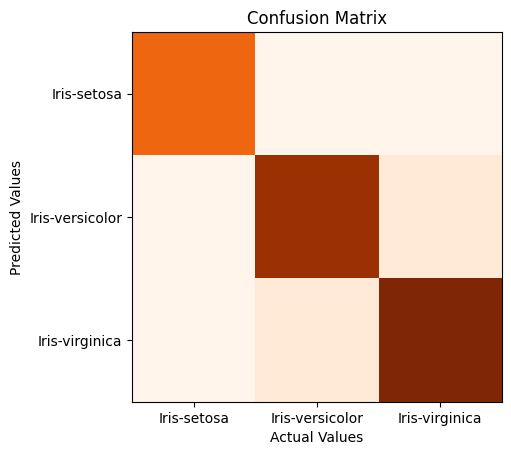

In [67]:
y_pred = np.array([predict(sample) for sample in test_X])

cm = np.zeros((3,3), dtype=int)

for true, pred in zip(test_Y, y_pred):
    cm[true][pred] += 1

plt.imshow(cm, cmap="Oranges")
plt.title("Confusion Matrix")
plt.xticks([0,1,2], [c for c,_ in species_to_num.items()])
plt.yticks([0,1,2], [c for c,_ in species_to_num.items()])
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

In [68]:
print("Enter sample values to predict")

sl = float(input("Enter sample Sepal Length"))
sw = float(input("Enter sample Sepal Width"))
pl = float(input("Enter sample Petal Length"))
pw = float(input("Enter sample Petal Width"))

test_point = [sl,sw,pl,pw]

prediction = predict(test_point)
print(f"It is a {num_to_species[prediction]}")

Enter sample values to predict


Enter sample Sepal Length 3.2
Enter sample Sepal Width 1.5
Enter sample Petal Length 3.
Enter sample Petal Width 1.


It is a Iris-versicolor
